In [2]:
import os
print(os.getcwd())


/Users/williambroderick


In [8]:
import pandas as pd

# ============================================
# 1. Load Weather Data
# ============================================
temp = pd.read_csv("Temp.Wales.Data_2015-2025.csv")
rain = pd.read_csv("Rain.Wales.Data_2015-2025.csv")
sunshine = pd.read_csv("Sunshine.Wales.Dataimport os
print(os.getcwd())
_2015-2025.csv")

temp = temp.rename(columns={'ann': 'temperature'})
rain = rain.rename(columns={'ann': 'rainfall'})
sunshine = sunshine.rename(columns={'ann': 'sunshine'})

print("Weather data loaded successfully!")

# ============================================
# 2. Load and Clean Wheat Yield Data
# ============================================
yield_df = pd.read_csv("Wheat.Yields.Wales.Data_2015-2025.csv", index_col=0)
yield_wales = yield_df.loc["Wales"].to_frame()
yield_wales.columns = ['wheat_yield']
yield_wales['year'] = yield_wales.index
yield_wales = yield_wales.reset_index(drop=True)
yield_wales = yield_wales[['year', 'wheat_yield']]
yield_wales['year'] = yield_wales['year'].astype(str).str.replace(r'\(.*\)', '', regex=True).astype(int)
yield_wales['wheat_yield'] = pd.to_numeric(yield_wales['wheat_yield'], errors='coerce')

print("Wheat Yield data cleaned!")

# ============================================
# 3. Load and Clean Wheat Production Data (Robust Method)
# ============================================
prod_df = pd.read_csv("Wheat.Production.Wales.Data_2015-2025.csv", header=None)

# Transpose first
prod_transposed = prod_df.T

# Find the row that contains "Wales" in the first column
wales_row = prod_transposed[prod_transposed.iloc[:, 0] == "Wales"]

if len(wales_row) == 0:
    print("⚠️ Could not find 'Wales' row in production file!")
else:
    # Get the data from that row (skip the first column which is "Wales")
    prod_wales = wales_row.iloc[:, 1:].T
    prod_wales.columns = ['wheat_production']
    prod_wales['year'] = prod_wales.index
    prod_wales = prod_wales.reset_index(drop=True)
    prod_wales = prod_wales[['year', 'wheat_production']]
    
    # Clean year
    prod_wales['year'] = prod_wales['year'].astype(str).str.replace(r'\(.*\)', '', regex=True).astype(int)
    prod_wales['wheat_production'] = pd.to_numeric(prod_wales['wheat_production'], errors='coerce')

    print("Wheat Production data cleaned!")

    # ============================================
    # 4. Merge Everything
    # ============================================
    df = temp.merge(rain, on='year', how='inner')
    df = df.merge(sunshine, on='year', how='inner')
    df = df.merge(yield_wales, on='year', how='inner')
    df = df.merge(prod_wales, on='year', how='inner')

    df = df.sort_values('year').reset_index(drop=True)

    print("\n✅ Final clean dataset created!")
    print(df)
    print(f"\nShape: {df.shape}")
    print(f"Years covered: {df['year'].min()} to {df['year'].max()}")
    

Weather data loaded successfully!
Wheat Yield data cleaned!
⚠️ Could not find 'Wales' row in production file!


In [9]:
import pandas as pd

prod_df = pd.read_csv("Wheat.Production.Wales.Data_2015-2025.csv", header=None)
prod_transposed = prod_df.T

print("First 10 rows after transposing:")
print(prod_transposed.head(10))

print("\n\nUnique values in the first column:")
print(prod_transposed.iloc[:, 0].unique())

First 10 rows after transposing:
                0               1        2
0  Production (2)  United Kingdom    Wales
1            2015     16444228.99  176,423
2            2016     14383276.03  156,732
3            2017     14836963.31  158,349
4            2018     13554842.64  152,308
5            2019     16224510.73  189,721
6            2020      9657885.04  134,732
7            2021     13987677.47  170,729
8         2022(1)     15539652.47  208,883
9            2023     13979847.79  180,979


Unique values in the first column:
['Production (2)' '2015' '2016' '2017' '2018' '2019' '2020' '2021'
 '2022(1)' '2023' '2024' '2025' nan]


In [10]:
import pandas as pd

# ============================================
# 1. Load Weather Data
# ============================================
temp = pd.read_csv("Temp.Wales.Data_2015-2025.csv")
rain = pd.read_csv("Rain.Wales.Data_2015-2025.csv")
sunshine = pd.read_csv("Sunshine.Wales.Data_2015-2025.csv")

temp = temp.rename(columns={'ann': 'temperature'})
rain = rain.rename(columns={'ann': 'rainfall'})
sunshine = sunshine.rename(columns={'ann': 'sunshine'})

print("Weather data loaded successfully!")

# ============================================
# 2. Load and Clean Wheat Yield Data
# ============================================
yield_df = pd.read_csv("Wheat.Yields.Wales.Data_2015-2025.csv", index_col=0)
yield_wales = yield_df.loc["Wales"].to_frame()
yield_wales.columns = ['wheat_yield']
yield_wales['year'] = yield_wales.index
yield_wales = yield_wales.reset_index(drop=True)
yield_wales = yield_wales[['year', 'wheat_yield']]
yield_wales['year'] = yield_wales['year'].astype(str).str.replace(r'\(.*\)', '', regex=True).astype(int)
yield_wales['wheat_yield'] = pd.to_numeric(yield_wales['wheat_yield'], errors='coerce')

print("Wheat Yield data cleaned!")

# ============================================
# 3. Load and Clean Wheat Production Data (Correct Structure)
# ============================================
prod_df = pd.read_csv("Wheat.Production.Wales.Data_2015-2025.csv", header=None)

# Drop empty columns
prod_df = prod_df.dropna(axis=1, how='all')

# Transpose
prod_transposed = prod_df.T

# Set proper column names
prod_transposed.columns = ['year', 'UK', 'Wales']

# Keep only year and Wales columns
prod_wales = prod_transposed[['year', 'Wales']].copy()
prod_wales.columns = ['year', 'wheat_production']

# Remove header row (where year = "Production (2)")
prod_wales = prod_wales[prod_wales['year'] != 'Production (2)']

# Clean year column
prod_wales['year'] = prod_wales['year'].astype(str).str.replace(r'\(.*\)', '', regex=True).astype(int)

# Clean production values (remove commas and convert to number)
prod_wales['wheat_production'] = prod_wales['wheat_production'].astype(str).str.replace(',', '', regex=False)
prod_wales['wheat_production'] = pd.to_numeric(prod_wales['wheat_production'], errors='coerce')

print("Wheat Production data cleaned!")

# ============================================
# 4. Merge Everything
# ============================================
df = temp.merge(rain, on='year', how='inner')
df = df.merge(sunshine, on='year', how='inner')
df = df.merge(yield_wales, on='year', how='inner')
df = df.merge(prod_wales, on='year', how='inner')

df = df.sort_values('year').reset_index(drop=True)

print("\n✅ Final clean dataset created!")
print(df)
print(f"\nShape: {df.shape}")
print(f"Years covered: {df['year'].min()} to {df['year'].max()}")

Weather data loaded successfully!
Wheat Yield data cleaned!
Wheat Production data cleaned!

✅ Final clean dataset created!
    year  temperature  rainfall  sunshine  wheat_yield  wheat_production
0   2015         9.47    1568.6    1468.2          8.1            176423
1   2016         9.61    1371.0    1430.4          7.3            156732
2   2017         9.88    1415.4    1324.0          7.4            158349
3   2018         9.71    1367.2    1549.2          6.9            152308
4   2019         9.67    1604.6    1418.1          8.1            189721
5   2020         9.91    1746.7    1487.1          6.3            134732
6   2021         9.63    1497.5    1399.8          7.4            170729
7   2022        10.23    1293.4    1516.1          7.9            208883
8   2023        10.40    1725.3    1362.3          7.3            180979
9   2024         9.99    1647.3    1214.4          6.6            150162
10  2025        10.31    1446.3    1625.8          6.4            178038



In [11]:
# ============================================
# Basic Statistics
# ============================================
print("=== Descriptive Statistics ===")
print(df.describe().round(2))

print("\n=== Average values per year ===")
print(df.groupby('year').mean().round(2))

# ============================================
# Trends: First year vs Last year
# ============================================
print("\n=== Change from 2015 to 2025 ===")

first_year = df[df['year'] == 2015].iloc[0]
last_year = df[df['year'] == 2025].iloc[0]

change = pd.DataFrame({
    '2015': first_year,
    '2025': last_year,
    'Change': last_year - first_year,
    'Change_%': ((last_year - first_year) / first_year * 100).round(1)
})

print(change[['2015', '2025', 'Change', 'Change_%']].round(2))

# ============================================
# Simple Trend Direction
# ============================================
print("\n=== Overall Trend (2015-2025) ===")
for col in ['temperature', 'rainfall', 'sunshine', 'wheat_yield', 'wheat_production']:
    start = df[df['year'] == 2015][col].values[0]
    end = df[df['year'] == 2025][col].values[0]
    direction = "↑ Increased" if end > start else "↓ Decreased"
    print(f"{col:20} : {direction}")

=== Descriptive Statistics ===
          year  temperature  rainfall  sunshine  wheat_yield  wheat_production
count    11.00        11.00     11.00     11.00        11.00             11.00
mean   2020.00         9.89   1516.66   1435.95         7.25         168823.27
std       3.32         0.31    152.62    112.98         0.64          20915.73
min    2015.00         9.47   1293.40   1214.40         6.30         134732.00
25%    2017.50         9.65   1393.20   1381.05         6.75         154520.00
50%    2020.00         9.88   1497.50   1430.40         7.30         170729.00
75%    2022.50        10.11   1625.95   1501.60         7.65         179508.50
max    2025.00        10.40   1746.70   1625.80         8.10         208883.00

=== Average values per year ===
      temperature  rainfall  sunshine  wheat_yield  wheat_production
year                                                                
2015         9.47    1568.6    1468.2          8.1          176423.0
2016         9.61 

In [12]:
# ============================================
# Correlation Analysis
# ============================================

print("=== Correlation Matrix ===")
corr_matrix = df[['temperature', 'rainfall', 'sunshine', 'wheat_yield']].corr().round(3)
print(corr_matrix)

print("\n=== Correlation with Wheat Yield (sorted) ===")
corr_with_yield = df[['temperature', 'rainfall', 'sunshine']].corrwith(df['wheat_yield']).sort_values(ascending=False)
print(corr_with_yield.round(3))

# Optional: Add interpretation
print("\n=== Quick Interpretation ===")
for var in ['temperature', 'rainfall', 'sunshine']:
    corr_value = df[var].corr(df['wheat_yield'])
    if corr_value > 0.5:
        strength = "Strong positive"
    elif corr_value > 0.3:
        strength = "Moderate positive"
    elif corr_value > 0:
        strength = "Weak positive"
    elif corr_value < -0.5:
        strength = "Strong negative"
    elif corr_value < -0.3:
        strength = "Moderate negative"
    else:
        strength = "Weak negative"
    print(f"{var:12} → {strength} correlation with wheat yield ({corr_value:.3f})")

=== Correlation Matrix ===
             temperature  rainfall  sunshine  wheat_yield
temperature        1.000     0.108     0.086       -0.367
rainfall           0.108     1.000    -0.393       -0.238
sunshine           0.086    -0.393     1.000       -0.093
wheat_yield       -0.367    -0.238    -0.093        1.000

=== Correlation with Wheat Yield (sorted) ===
sunshine      -0.093
rainfall      -0.238
temperature   -0.367
dtype: float64

=== Quick Interpretation ===
temperature  → Moderate negative correlation with wheat yield (-0.367)
rainfall     → Weak negative correlation with wheat yield (-0.238)
sunshine     → Weak negative correlation with wheat yield (-0.093)


In [13]:
# ============================================
# 1. Identify Extreme Years
# ============================================
print("=== Top 3 Years with Highest Wheat Yield ===")
print(df.nlargest(3, 'wheat_yield')[['year', 'wheat_yield', 'temperature', 'rainfall', 'sunshine']])

print("\n=== Top 3 Years with Lowest Wheat Yield ===")
print(df.nsmallest(3, 'wheat_yield')[['year', 'wheat_yield', 'temperature', 'rainfall', 'sunshine']])

# ============================================
# 2. Focus on 2020 (Interesting Year)
# ============================================
print("\n=== 2020 Analysis (High rainfall, Low yield) ===")
print(df[df['year'] == 2020][['year', 'wheat_yield', 'temperature', 'rainfall', 'sunshine']])

# Compare 2020 with average
avg_yield = df['wheat_yield'].mean()
avg_rain = df['rainfall'].mean()

print(f"\nAverage wheat yield (2015-2025): {avg_yield:.2f} t/ha")
print(f"2020 wheat yield: {df[df['year']==2020]['wheat_yield'].values[0]} t/ha")
print(f"→ 2020 was {((df[df['year']==2020]['wheat_yield'].values[0] - avg_yield) / avg_yield * 100):.1f}% below average")

print(f"\nAverage rainfall: {avg_rain:.1f} mm")
print(f"2020 rainfall: {df[df['year']==2020]['rainfall'].values[0]} mm")
print(f"→ 2020 was {((df[df['year']==2020]['rainfall'].values[0] - avg_rain) / avg_rain * 100):.1f}% above average")

# ============================================
# 3. Years with Highest Temperature
# ============================================
print("\n=== Years with Highest Temperature ===")
print(df.nlargest(3, 'temperature')[['year', 'temperature', 'wheat_yield']])

=== Top 3 Years with Highest Wheat Yield ===
   year  wheat_yield  temperature  rainfall  sunshine
0  2015          8.1         9.47    1568.6    1468.2
4  2019          8.1         9.67    1604.6    1418.1
7  2022          7.9        10.23    1293.4    1516.1

=== Top 3 Years with Lowest Wheat Yield ===
    year  wheat_yield  temperature  rainfall  sunshine
5   2020          6.3         9.91    1746.7    1487.1
10  2025          6.4        10.31    1446.3    1625.8
9   2024          6.6         9.99    1647.3    1214.4

=== 2020 Analysis (High rainfall, Low yield) ===
   year  wheat_yield  temperature  rainfall  sunshine
5  2020          6.3         9.91    1746.7    1487.1

Average wheat yield (2015-2025): 7.25 t/ha
2020 wheat yield: 6.3 t/ha
→ 2020 was -13.0% below average

Average rainfall: 1516.7 mm
2020 rainfall: 1746.7 mm
→ 2020 was 15.2% above average

=== Years with Highest Temperature ===
    year  temperature  wheat_yield
8   2023        10.40          7.3
10  2025        10

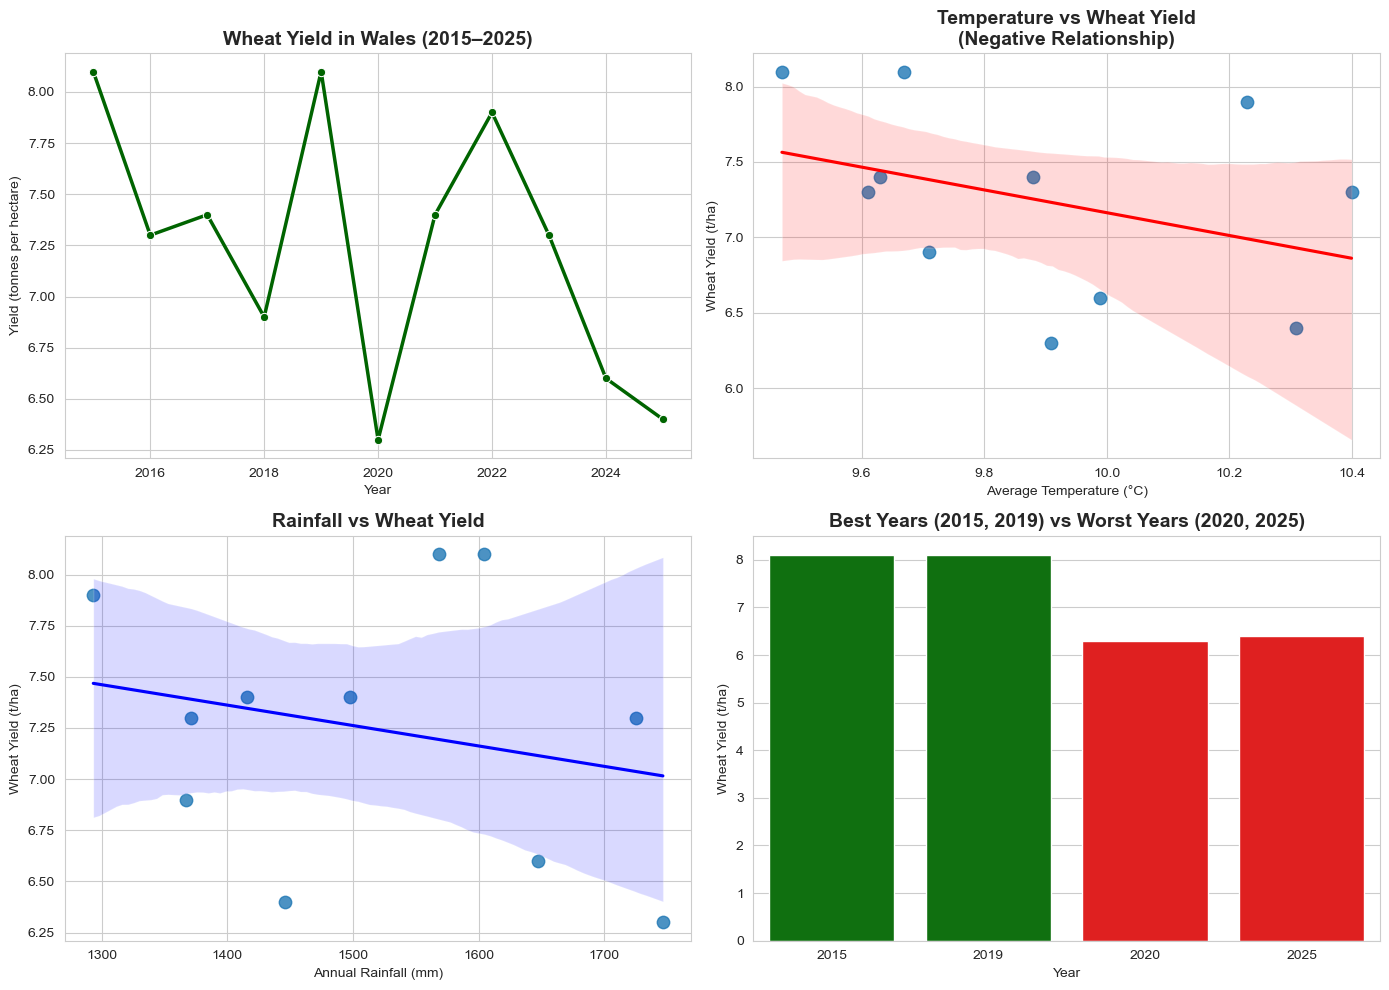

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

# Chart 1: Wheat Yield Trend
plt.subplot(2, 2, 1)
sns.lineplot(data=df, x='year', y='wheat_yield', marker='o', linewidth=2.5, color='darkgreen')
plt.title('Wheat Yield in Wales (2015–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Yield (tonnes per hectare)')

# Chart 2: Temperature vs Wheat Yield
plt.subplot(2, 2, 2)
sns.regplot(data=df, x='temperature', y='wheat_yield', scatter_kws={'s': 80}, line_kws={'color': 'red'})
plt.title('Temperature vs Wheat Yield\n(Negative Relationship)', fontsize=14, fontweight='bold')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Wheat Yield (t/ha)')

# Chart 3: Rainfall vs Wheat Yield
plt.subplot(2, 2, 3)
sns.regplot(data=df, x='rainfall', y='wheat_yield', scatter_kws={'s': 80}, line_kws={'color': 'blue'})
plt.title('Rainfall vs Wheat Yield', fontsize=14, fontweight='bold')
plt.xlabel('Annual Rainfall (mm)')
plt.ylabel('Wheat Yield (t/ha)')

# Chart 4: Best vs Worst Years (Fixed)
plt.subplot(2, 2, 4)
best_worst = df[df['year'].isin([2015, 2019, 2020, 2025])]
sns.barplot(data=best_worst, x='year', y='wheat_yield', 
            hue='year', palette=['green', 'green', 'red', 'red'], legend=False)
plt.title('Best Years (2015, 2019) vs Worst Years (2020, 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Wheat Yield (t/ha)')

plt.tight_layout()
plt.show()

✅ Chart saved successfully as: charts/wheat_weather_analysis_wales.png


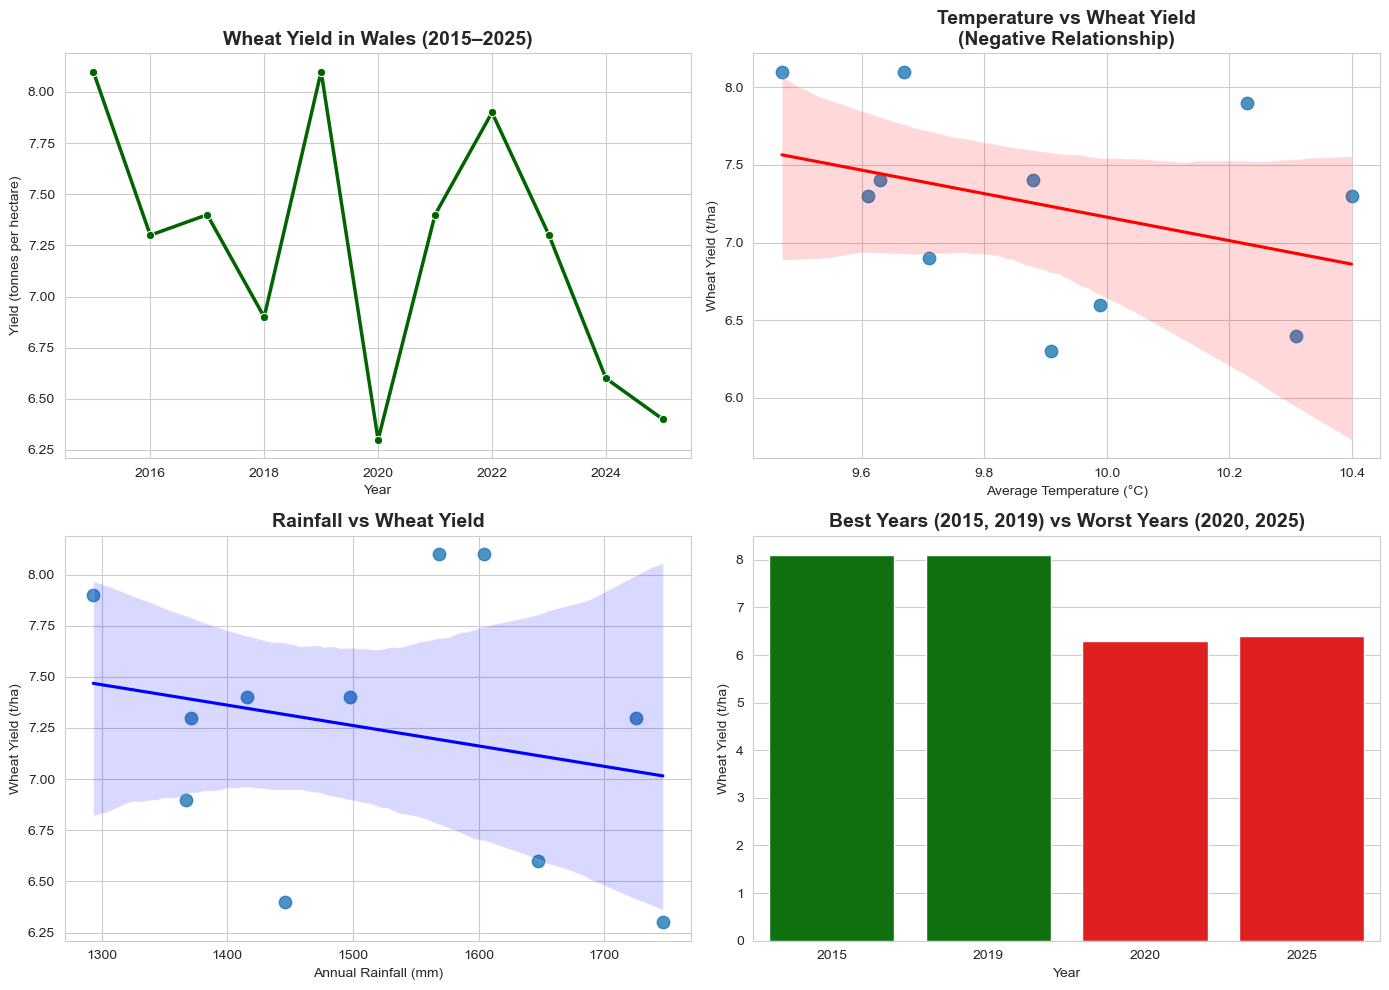

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a folder to save charts (if it doesn't exist)
if not os.path.exists("charts"):
    os.makedirs("charts")

sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

# Chart 1: Wheat Yield Trend
plt.subplot(2, 2, 1)
sns.lineplot(data=df, x='year', y='wheat_yield', marker='o', linewidth=2.5, color='darkgreen')
plt.title('Wheat Yield in Wales (2015–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Yield (tonnes per hectare)')

# Chart 2: Temperature vs Wheat Yield
plt.subplot(2, 2, 2)
sns.regplot(data=df, x='temperature', y='wheat_yield', scatter_kws={'s': 80}, line_kws={'color': 'red'})
plt.title('Temperature vs Wheat Yield\n(Negative Relationship)', fontsize=14, fontweight='bold')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Wheat Yield (t/ha)')

# Chart 3: Rainfall vs Wheat Yield
plt.subplot(2, 2, 3)
sns.regplot(data=df, x='rainfall', y='wheat_yield', scatter_kws={'s': 80}, line_kws={'color': 'blue'})
plt.title('Rainfall vs Wheat Yield', fontsize=14, fontweight='bold')
plt.xlabel('Annual Rainfall (mm)')
plt.ylabel('Wheat Yield (t/ha)')

# Chart 4: Best vs Worst Years
plt.subplot(2, 2, 4)
best_worst = df[df['year'].isin([2015, 2019, 2020, 2025])]
sns.barplot(data=best_worst, x='year', y='wheat_yield', 
            hue='year', palette=['green', 'green', 'red', 'red'], legend=False)
plt.title('Best Years (2015, 2019) vs Worst Years (2020, 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Wheat Yield (t/ha)')

plt.tight_layout()

# Save the figure as high-quality PNG
plt.savefig("charts/wheat_weather_analysis_wales.png", dpi=300, bbox_inches='tight')

print("✅ Chart saved successfully as: charts/wheat_weather_analysis_wales.png")
plt.show()

**Figure 1:** Wheat Yield and Weather Analysis in Wales (2015–2025)

![Wheat Weather Analysis](charts/wheat_weather_analysis_wales.png)

## Insights and Recommendations

Insights and Recommendations
Key Insights

Wheat yield in Wales declined significantly by 21% between 2015 and 2025, dropping from 8.1 t/ha to 6.4 t/ha.
Temperature showed a moderate negative correlation with wheat yield (-0.367). Warmer years tended to have lower yields.
Excessive rainfall appears harmful. The year 2020 had the highest rainfall (+15% above average) and the lowest yield of the period (6.3 t/ha).
Moderate weather conditions performed best. The highest yields occurred in 2015 and 2019, which had relatively balanced temperature and rainfall.
Wheat production remained relatively stable (+0.9%) despite the drop in yield per hectare, suggesting farmers may have increased planted area in some years to compensate.

Implications

Rising temperatures and changing rainfall patterns may be creating more challenging growing conditions for wheat in Wales.
Both heat stress and waterlogging (from excessive rain) appear to negatively affect yields.
The Welsh wheat sector may face increasing pressure if current climate trends continue.

Recommendations
For Farmers:

Consider adopting heat and drought-tolerant wheat varieties.
Improve field drainage to reduce the impact of heavy rainfall events.
Monitor weather forecasts closely during critical growth stages (especially flowering and grain filling).

For Agtech Companies:

There is clear potential for tools focused on:
Weather-based decision support systems for wheat growers in Wales.
Precision irrigation and drainage technologies.
Early warning systems for extreme weather events (heavy rain or heatwaves).


For Policymakers and Industry Bodies:

Support research into climate-resilient wheat varieties suitable for Welsh conditions.
Provide targeted advice and subsidies for drainage infrastructure improvements.
Encourage data-driven farming practices through training and technology adoption programs.